# Analisis del Dataset, comprobacion y agrupacion de variables de Generacion Por Tipos de Energia

### 1 Analisis del Dataset y estudio de las variables

1. Dimensiones y valores nulos
2. Calidad e integridad temporal
3. Numero de observaciones por mes/año
4. Comprobar variables temporales
5. Distribución del precio (Histograma)
6. Matriz de correlacion
7. Matriz de Correlacion-Precio
8. Correlacion absoluta especto al precio

Filas: 43,848
Columnas: 31

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   datetime                         43848 non-null  str    
 1   demand                           43848 non-null  float64
 2   year                             43848 non-null  int64  
 3   month                            43848 non-null  int64  
 4   day                              43848 non-null  int64  
 5   dayofweek                        43848 non-null  int64  
 6   is_weekend                       43848 non-null  int64  
 7   biogas                           43848 non-null  float64
 8   biomasa                          43848 non-null  float64
 9   ciclo_combinado                  43848 non-null  float64
 10  derivados_del_petroleo_o_carbon  43848 non-null  float64
 11  energia_residual                 43848 non-null  float64
 12  e

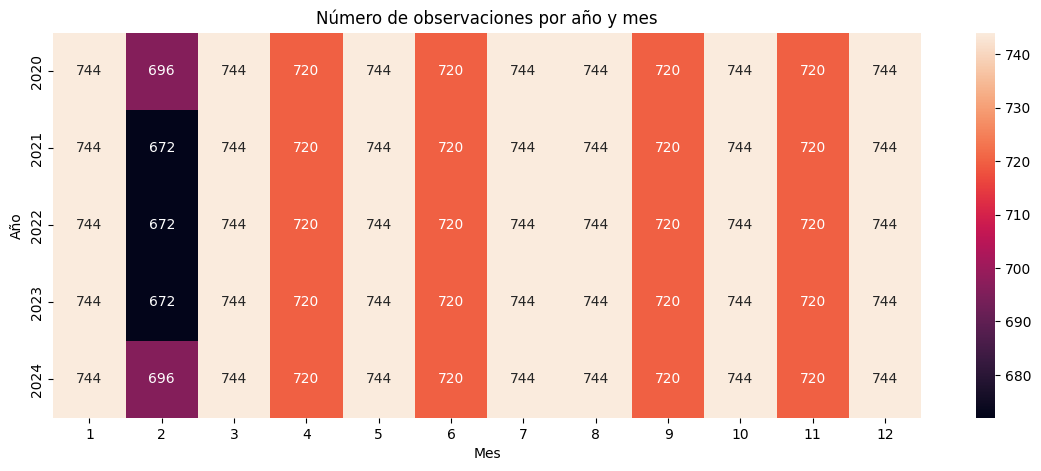

Errores en is_weekend: 0


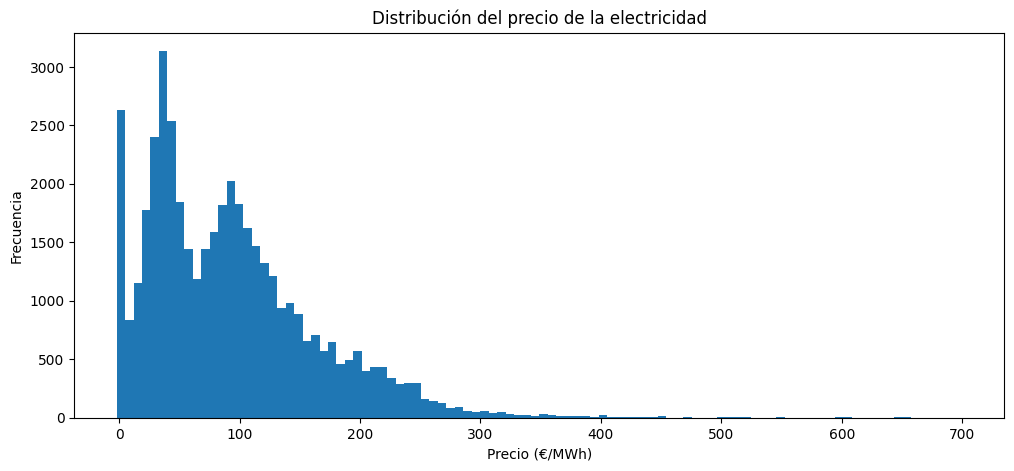

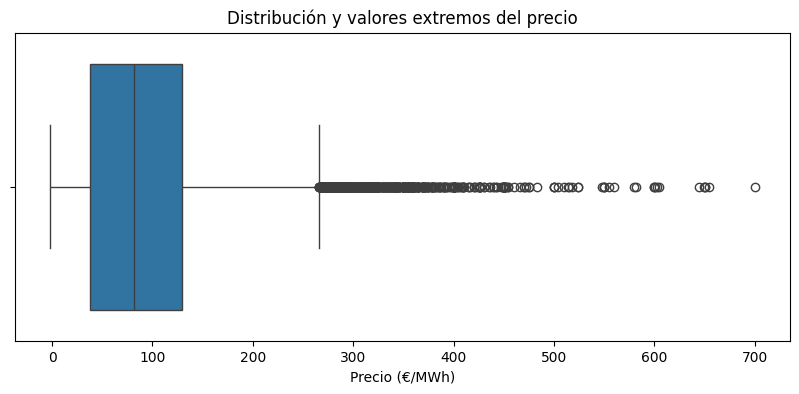


Matriz de correlación entre variables numéricas:



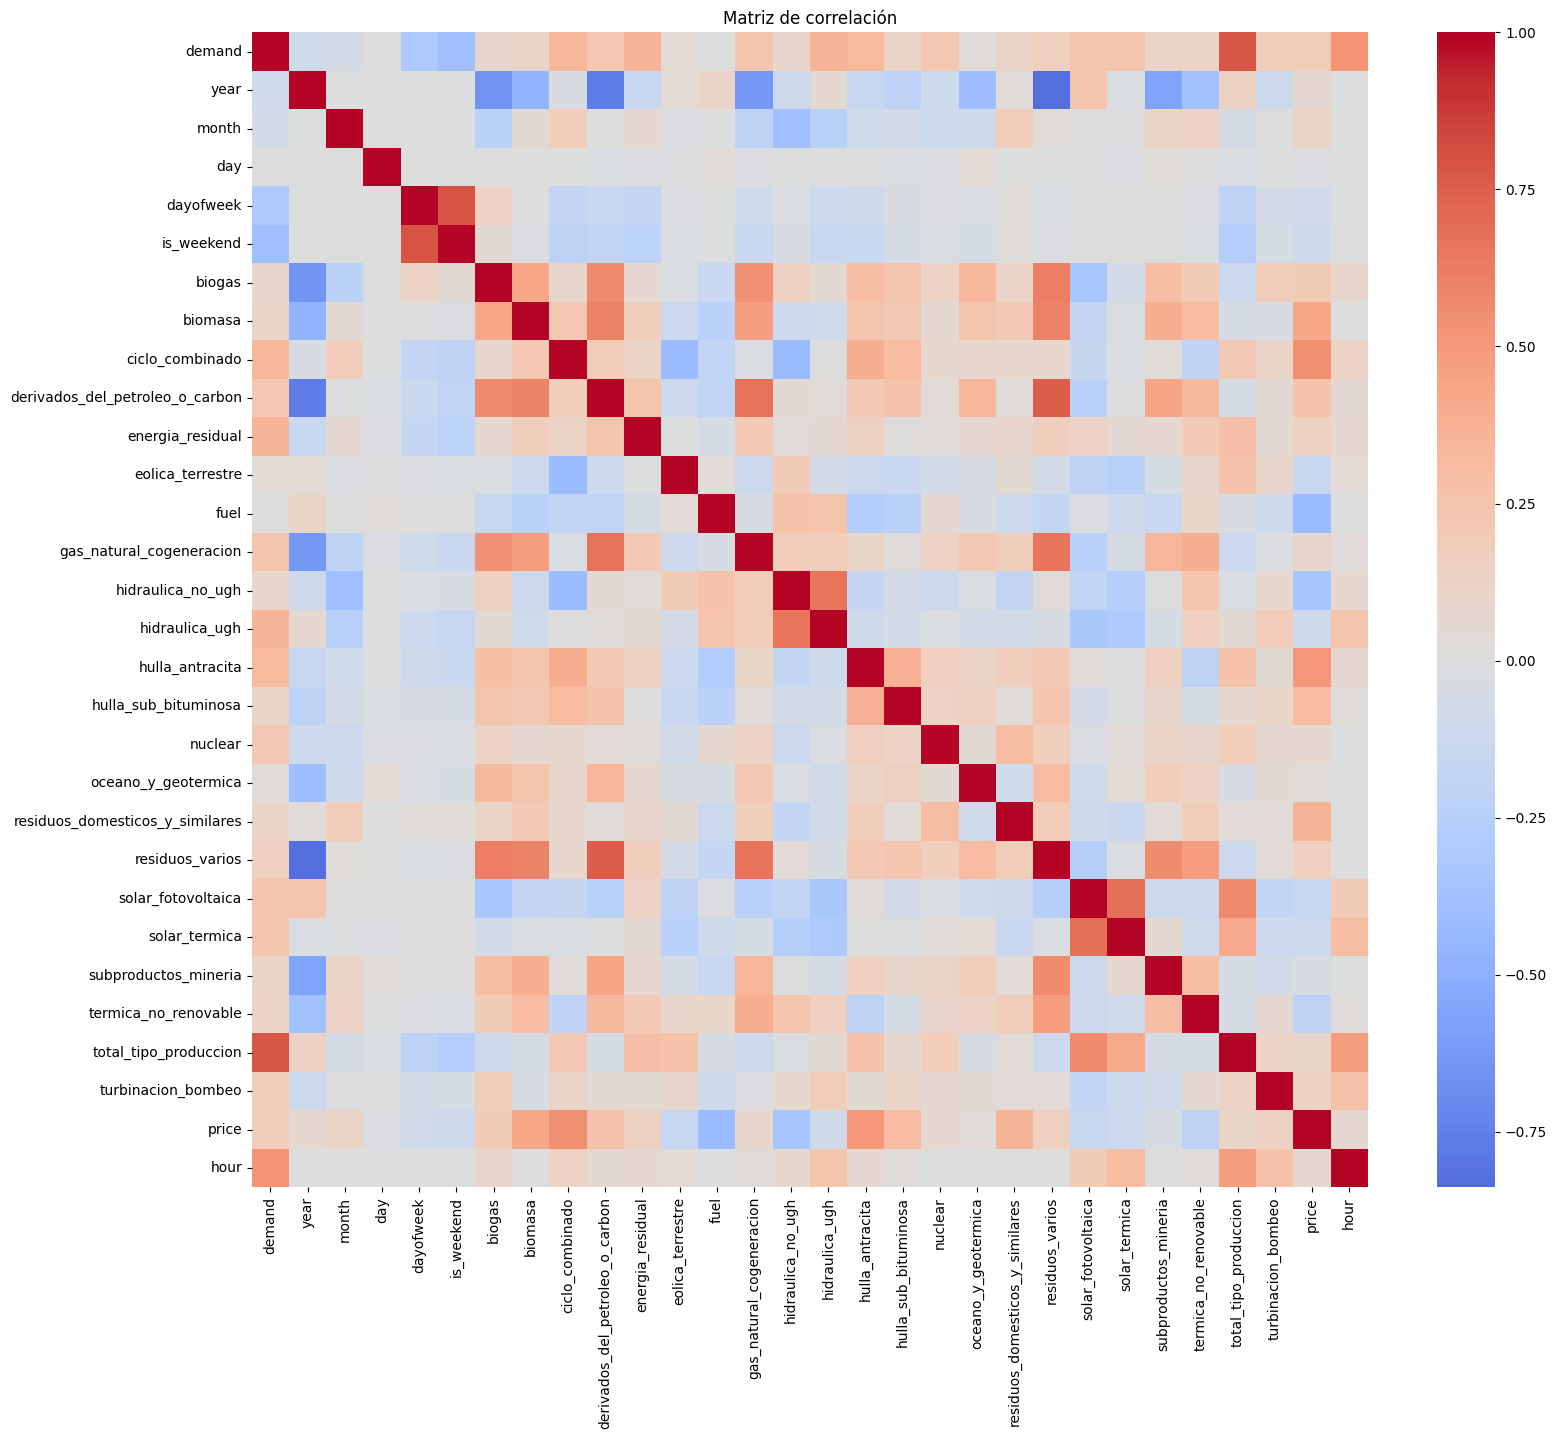


Correlación de cada variable con el precio:



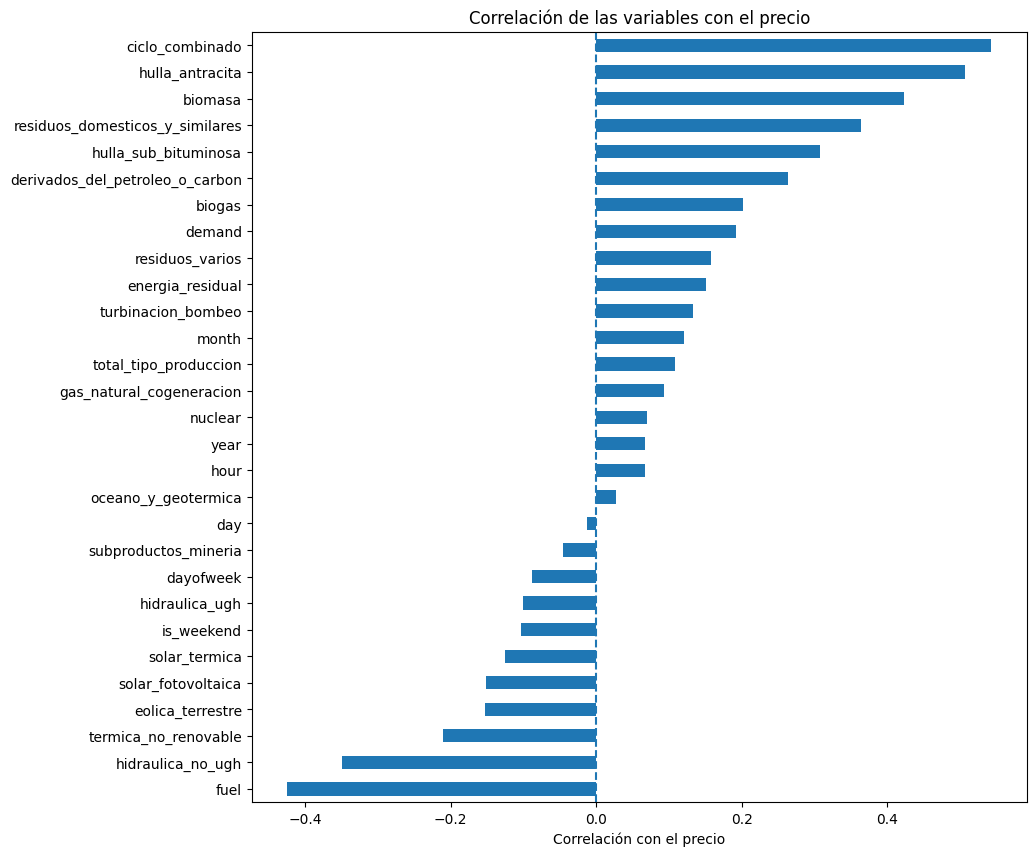

,Tecnología,Correlación con precio
0,ciclo_combinado,0.542858
1,hulla_antracita,0.506014
2,biomasa,0.422579
3,residuos_domesticos_y_similares,0.363387
4,hulla_sub_bituminosa,0.307477
5,derivados_del_petroleo_o_carbon,0.262672
6,biogas,0.201830
7,residuos_varios,0.157181
8,energia_residual,0.151177
9,turbinacion_bombeo,0.133124


,Tecnología,Correlación con precio
0,ciclo_combinado,0.542858
1,hulla_antracita,0.506014
2,biomasa,0.422579
3,residuos_domesticos_y_similares,0.363387
4,hulla_sub_bituminosa,0.307477
5,derivados_del_petroleo_o_carbon,0.262672
6,biogas,0.201830
7,residuos_varios,0.157181
8,energia_residual,0.151177
9,turbinacion_bombeo,0.133124



Correlación absoluta de cada variable con el precio:

Variables con mayor correlación absoluta con el precio:
 ciclo_combinado                    0.542858
hulla_antracita                    0.506014
fuel                               0.424915
biomasa                            0.422579
residuos_domesticos_y_similares    0.363387
hidraulica_no_ugh                  0.349422
hulla_sub_bituminosa               0.307477
derivados_del_petroleo_o_carbon    0.262672
termica_no_renovable               0.210346
biogas                             0.201830
Name: price, dtype: float64 



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("Dataset_Unificado_2020_2024.csv", sep=";")

df.head()

# =========================
# 1 comprobamos dimensiones:
# =========================

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}\n")

#tipos de los datos:
df.info()

#Si hay valores nulos:
nulos = df.isnull().sum()

nulos = nulos[nulos > 0].sort_values(ascending=False)

print("\n Numero de valores nulos:", nulos.sum(), "\n")

print("\n")

# =========================
# 2 Comprobar el periodo temporal
# =========================

df["datetime"] = pd.to_datetime(df["datetime"])

#fechas de inicio y fin del dataset
print("fechas de inicio y fin del dataset")
print("Fecha mínima:", df["datetime"].min())
print("Fecha máxima:", df["datetime"].max(), "\n")

# Comprobar duplicados
duplicados_datetime = df["datetime"].duplicated().sum()
print("Timestamps(fechas) duplicados:", duplicados_datetime, "\n")


#Calculamos la diferencia entre observaciones:
diferencias = df["datetime"].diff()

diferencias.value_counts().sort_index()
#Normalmente deberías encontrar:  0 days 01:00:00

#print(diferencias, "\n")

# =========================
# 3 Comprobar número de observaciones por año y mes
# =========================

#print("Número de observaciones por año:")
df.groupby("year").size()

df.groupby("year")["datetime"].agg(["min", "max", "count"])

observaciones_mes = (
    df.groupby(["year", "month"])
      .size()
      .unstack(fill_value=0)
)

observaciones_mes

plt.figure(figsize=(14, 5))

sns.heatmap(
    observaciones_mes,
    annot=True,
    fmt="d"
)

plt.title("Número de observaciones por año y mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

# =========================
# 4 Comprobar las variables temporales
# =========================

#Podemos comprobar que son coherentes con datetime:
comprobacion = pd.DataFrame({
    "year_correcto": df["year"] == df["datetime"].dt.year,
    "month_correcto": df["month"] == df["datetime"].dt.month,
    "day_correcto": df["day"] == df["datetime"].dt.day,
    "dayofweek_correcto": df["dayofweek"] == df["datetime"].dt.dayofweek,
    "hour_correcto": df["hour"] == df["datetime"].dt.hour
})

comprobacion.sum()

is_weekend_correcto = (
    df["is_weekend"] ==
    df["datetime"].dt.dayofweek.isin([5, 6]).astype(int)
)

print("Errores en is_weekend:", (~is_weekend_correcto).sum())


# =========================
# 5 Analizar el precio
# =========================

df["price"].describe()

#Histograma
plt.figure(figsize=(12, 5))

plt.hist(df["price"], bins=100)

plt.xlabel("Precio (€/MWh)")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio de la electricidad")

plt.show()

# Diagrama de caja (boxplot) para detectar valores extremos
#Esto es particularmente interesante en electricidad porque el precio
#puede presentar valores extremos y episodios anomalos, incluidos precios
#negativos en determinados mercados/periodos

plt.figure(figsize=(10, 4))

sns.boxplot(x=df["price"])

plt.title("Distribución y valores extremos del precio")
plt.xlabel("Precio (€/MWh)")

plt.show()

# =========================
# 6 Matriz de correlación
# =========================
print("\nMatriz de correlación entre variables numéricas:\n")
df_numeric = df.select_dtypes(include=np.number)

correlacion = df_numeric.corr()

#print(correlacion, "\n")
plt.figure(figsize=(18, 15))

sns.heatmap(
    correlacion,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()


# =========================
# 7 Correlación de cada variable con el precio
# =========================
print("\nCorrelación de cada variable con el precio:\n")

corr_price = (
    df_numeric.corr()["price"]
    .drop("price")
    .sort_values()
)

plt.figure(figsize=(10, 10))

corr_price.plot(kind="barh")

plt.xlabel("Correlación con el precio")
plt.title("Correlación de las variables con el precio")

plt.axvline(0, linestyle="--")

plt.show()

#Columnas de las tecnologías de generación eléctrica
generacion_cols = [
    "biogas", "biomasa", "ciclo_combinado",
    "derivados_del_petroleo_o_carbon", "energia_residual",
    "eolica_terrestre", "fuel", "gas_natural_cogeneracion",
    "hidraulica_no_ugh", "hidraulica_ugh", "hulla_antracita",
    "hulla_sub_bituminosa", "nuclear", "oceano_y_geotermica",
    "residuos_domesticos_y_similares", "residuos_varios",
    "solar_fotovoltaica", "solar_termica", "subproductos_mineria",
    "termica_no_renovable", "turbinacion_bombeo"
]


# Calcular correlaciones con el precio
corr_price = df[generacion_cols].corrwith(df['price']).sort_values(ascending=False)

# Mostrar como tabla
tabla_corr = pd.DataFrame({
    'Tecnología': corr_price.index,
    'Correlación con precio': corr_price.values
})

# Mostrar simple (sin gradient)
display(tabla_corr)

# O con formato de número
display(tabla_corr)



# =========================
# 8 Correlación absoluta
# =========================

#Para encontrar las variables que mas relacion tienen con el precio
print("\nCorrelación absoluta de cada variable con el precio:\n")

corr_price_abs = (
    df_numeric.corr()["price"]
    .drop("price")
    .abs()
    .sort_values(ascending=False)
)

print("Variables con mayor correlación absoluta con el precio:\n", corr_price_abs.head(10), "\n")


### 2 Analisis previo de las variables de Generacion Por Tipo de Tecnologia para agrupacion

1. Mostrar evolucion por mes y año de las tecnologias con mas volumen de generacion

2. Crear una tabla de evaluación de tecnologías

    Calcula para cada tecnología:

    media, desviación estándar, coeficiente de variación, mínimo/máximo, porcentaje de ceros, Pearson con price, Spearman con price 

    ¿Por qué Pearson Y Spearman? Porque puede ser que la relación con el precio no es exclusivamente lineal:

    Pearson -> relación lineal

    Spearman -> relación monotónica

    Si una variable tiene baja Pearson pero alta Spearman, hay información que la correlación lineal no está capturando.

3. Analisis de correlacion entre variables de generacion, detectar variables redundantes

    Es decir, poca correlacion con el precio. Pero cuidado:

    Baja correlacion no significa variable inutil. Una variable puede aportar información no lineal o interactuar con otras.

4. Heatmap de correlacion entre variables de generacion

5. Deteccion pares de variables con correlación alta

    Nota: no aporta informacion relevante, con la matriz de correlacion se mejor las relaciones entre variables

6. Diferencia de la medida VIF 

    Como la correlacion de dos variables de una en una no detecta toda la multicolinealidad,
    para eso podemos comprobar tambien la Variance Inflation Factor (VIF). Esto  da una justificacion estadistica mucho mas solida para reducir variables

7. Comprobacion de la variable total_tipo_produccion

    La columna de total_tipo_produccion difiere de la suma de las variables de generacion por tipos de energia, dado que
    es un indicador que proviene de la suma de todos los datos del grupo PBF. En nuestro caso, no hemos seleccionado 
    todos lo elementos de ese grupo solo las tecnologias de generacion por lo que al contrastarlos vemos que no coinciden. Lo mejor seria que consideremos como redundante esta columna y eliminarla para el dataset final




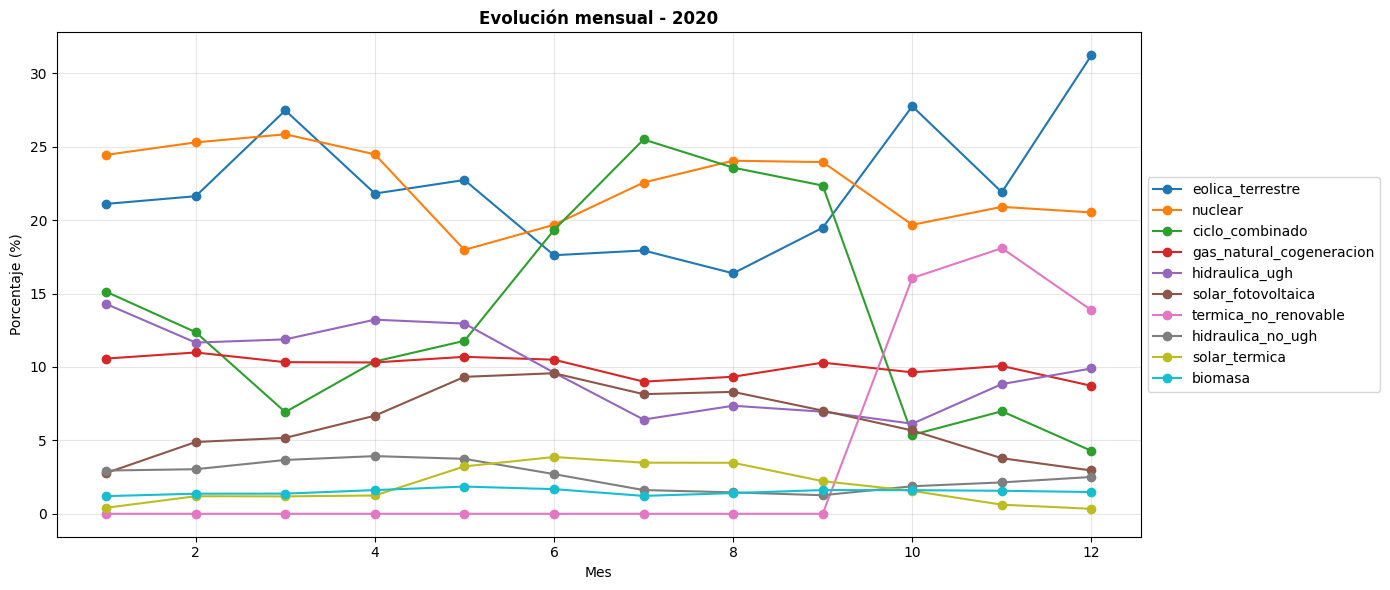

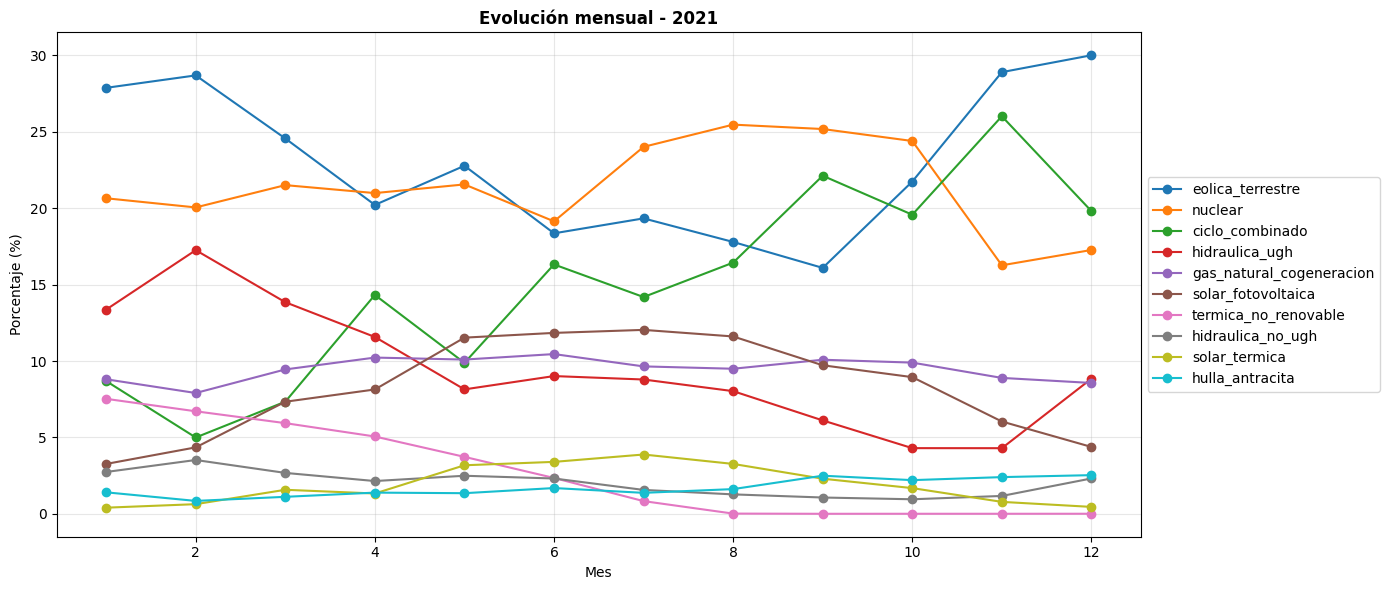

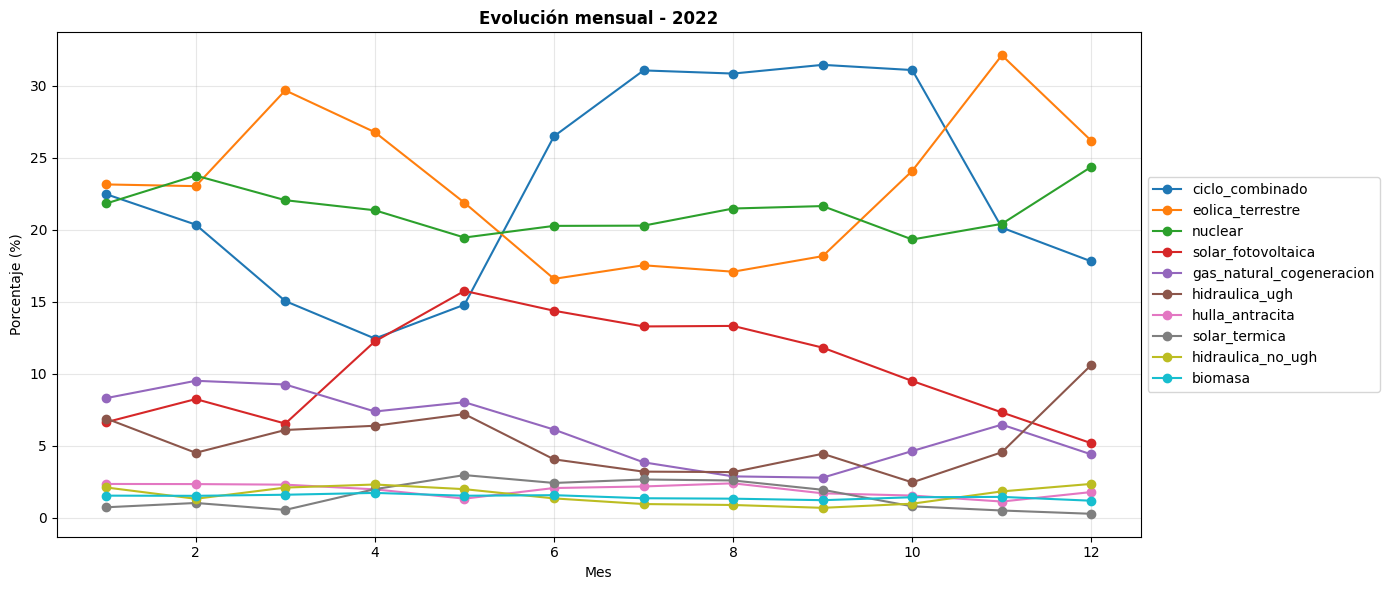

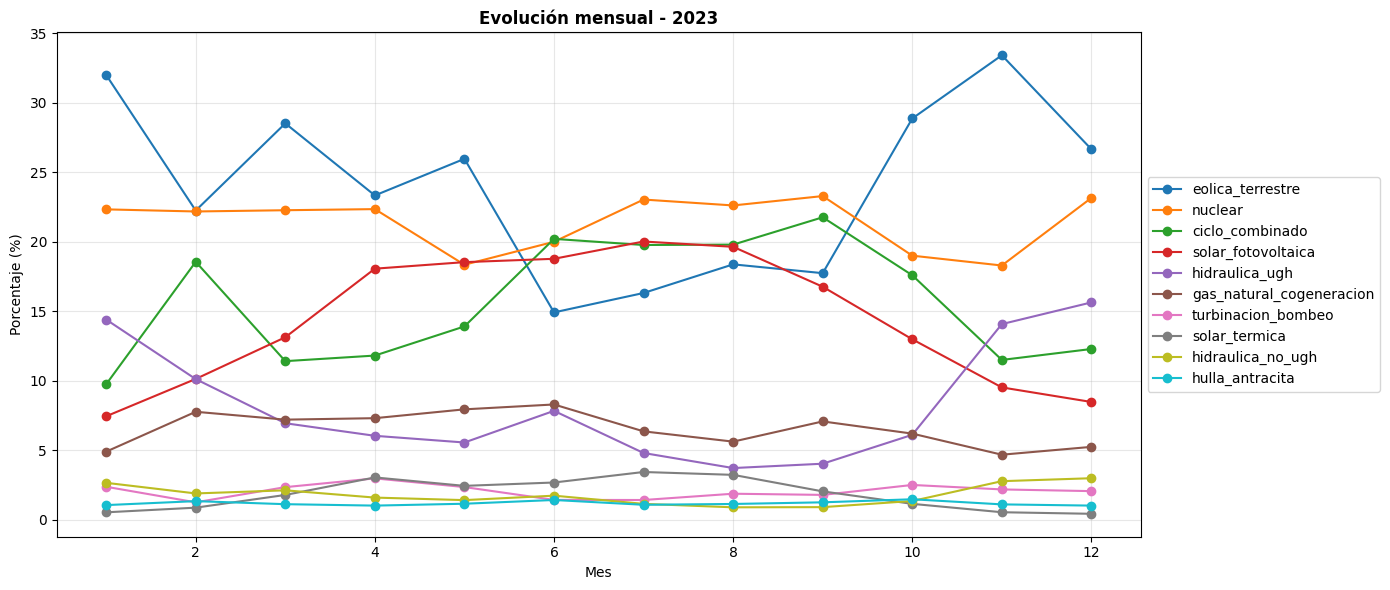

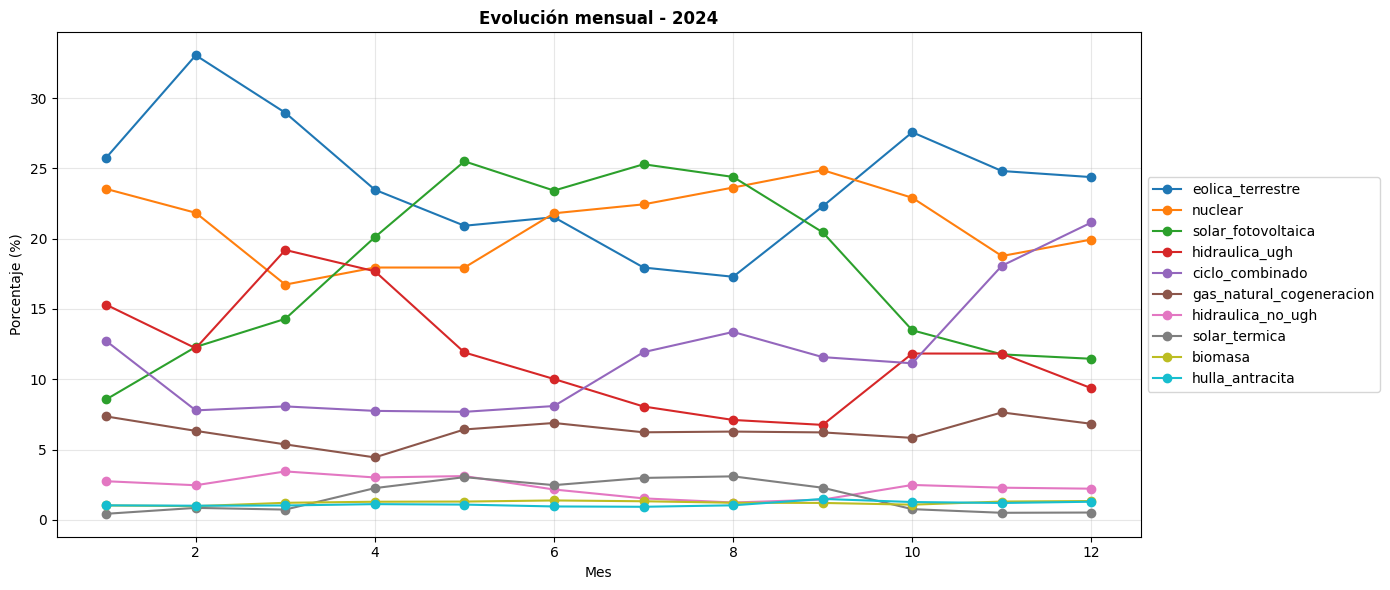

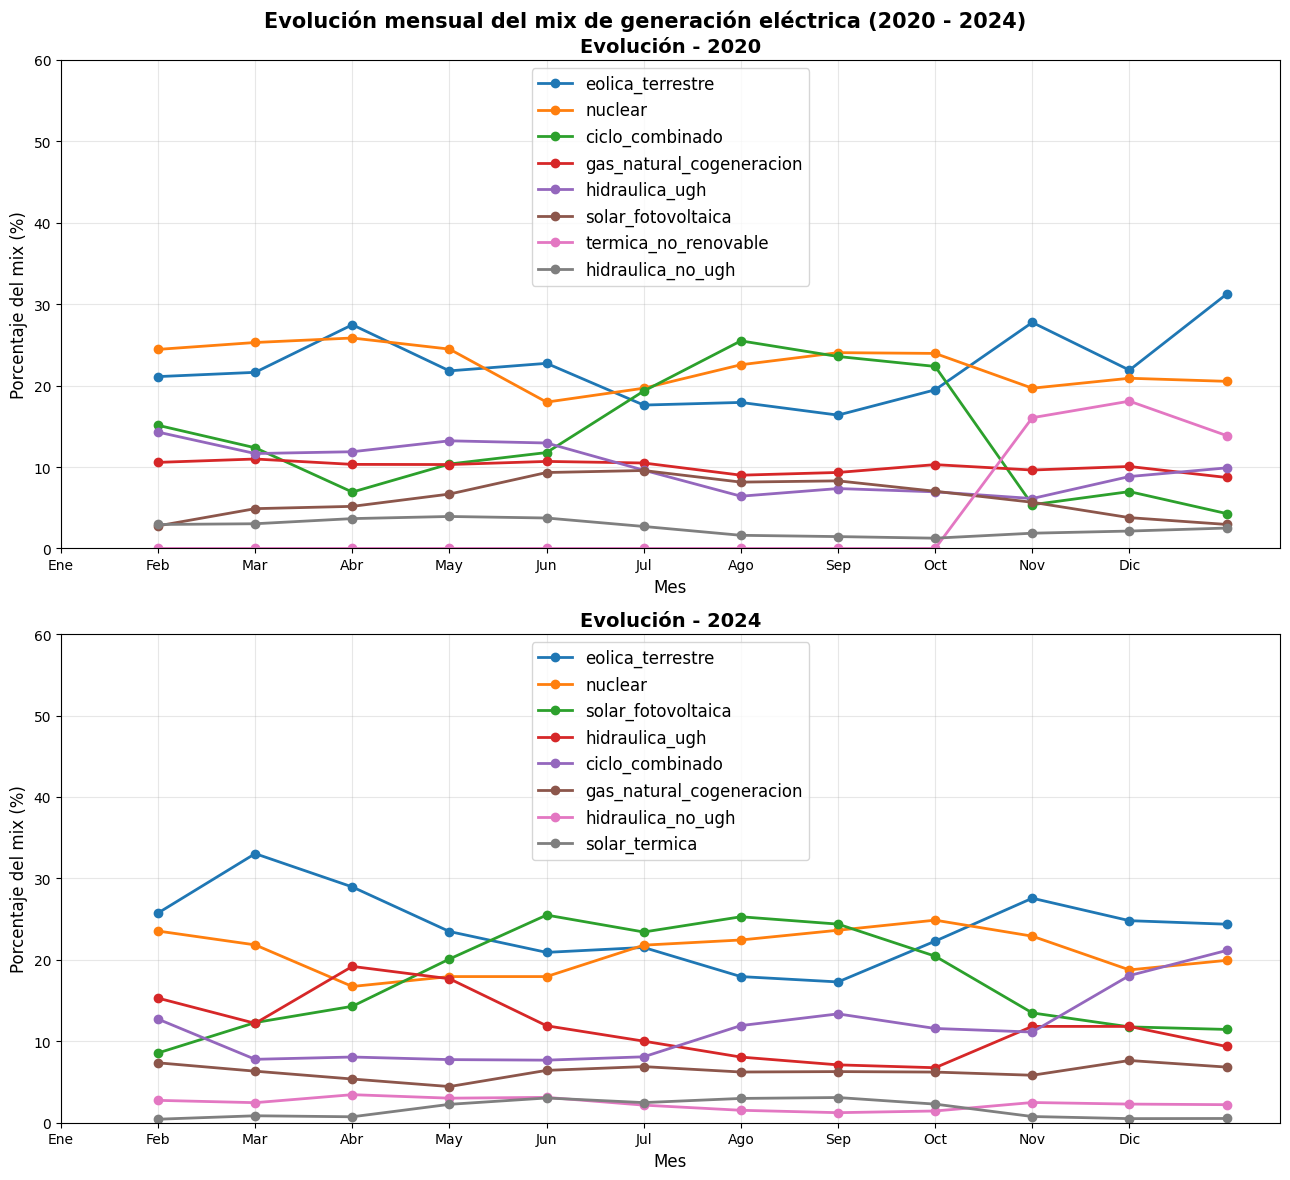

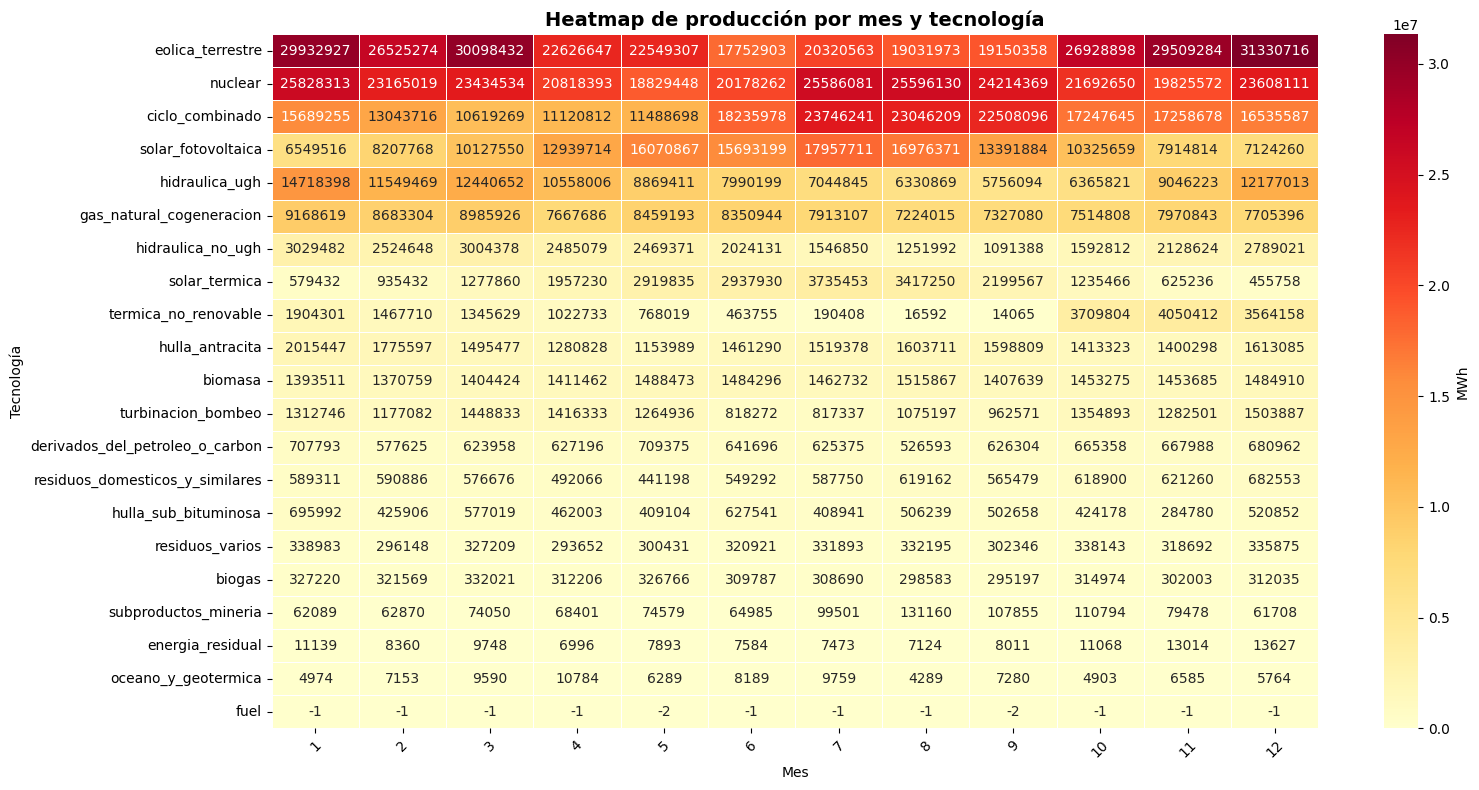

,media,std,cv,min,max,%_ceros,%_positivos,max_%_total,%_media_total,pearson_price,spearman_price
eolica_terrestre,6745.058,3960.360,0.587,128.833,20886.609,0.000,100.000,62.981,23.321,-0.152,-0.182
nuclear,6220.965,937.312,0.151,3194.408,7141.135,0.000,100.000,41.267,22.048,0.070,0.031
ciclo_combinado,4573.531,3228.378,0.706,18.600,17579.379,0.000,100.000,55.665,15.993,0.543,0.628
solar_fotovoltaica,3267.636,4566.847,1.398,-0.638,19923.091,0.000,99.314,60.533,10.193,-0.151,-0.072
hidraulica_ugh,2573.595,1754.649,0.682,-686.661,9104.452,0.000,98.798,36.908,9.093,-0.100,-0.098
gas_natural_cogeneracion,2211.524,650.671,0.294,633.114,3416.529,0.000,100.000,15.326,7.882,0.092,0.019
hidraulica_no_ugh,591.538,242.294,0.410,111.140,1288.231,0.000,100.000,6.318,2.107,-0.349,-0.423
solar_termica,508.038,623.760,1.228,0.000,2175.460,0.014,99.986,8.949,1.661,-0.125,-0.075
hulla_antracita,418.063,222.148,0.531,-31.019,1554.130,0.000,99.204,5.840,1.459,0.506,0.534
biomasa,395.253,81.005,0.205,91.432,568.492,0.000,100.000,2.829,1.407,0.423,0.384


\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & media & std & cv & min & max & %_ceros & %_positivos & max_%_total & %_media_total & pearson_price & spearman_price \\
\midrule
eolica_terrestre & 6745.058000 & 3960.360000 & 0.587000 & 128.833000 & 20886.609000 & 0.000000 & 100.000000 & 62.981000 & 23.321000 & -0.152000 & -0.182000 \\
nuclear & 6220.965000 & 937.312000 & 0.151000 & 3194.408000 & 7141.135000 & 0.000000 & 100.000000 & 41.267000 & 22.048000 & 0.070000 & 0.031000 \\
ciclo_combinado & 4573.531000 & 3228.378000 & 0.706000 & 18.600000 & 17579.379000 & 0.000000 & 100.000000 & 55.665000 & 15.993000 & 0.543000 & 0.628000 \\
solar_fotovoltaica & 3267.636000 & 4566.847000 & 1.398000 & -0.638000 & 19923.091000 & 0.000000 & 99.314000 & 60.533000 & 10.193000 & -0.151000 & -0.072000 \\
hidraulica_ugh & 2573.595000 & 1754.649000 & 0.682000 & -686.661000 & 9104.452000 & 0.000000 & 98.798000 & 36.908000 & 9.093000 & -0.100000 & -0.098000 \\
gas_natural_cogeneracion & 2211.524000 & 650.671000 & 0

,media,std,cv,min,max,%_ceros,pearson_price,spearman_price
ciclo_combinado,4573.531,3228.378,0.706,18.600,17579.379,0.000,0.543,0.628
hulla_antracita,418.063,222.148,0.531,-31.019,1554.130,0.000,0.506,0.534
fuel,-0.000,0.001,1.833,-0.001,0.001,13.111,-0.425,-0.440
biomasa,395.253,81.005,0.205,91.432,568.492,0.000,0.423,0.384
residuos_domesticos_y_similares,158.149,38.581,0.244,34.797,219.892,0.000,0.363,0.387
hidraulica_no_ugh,591.538,242.294,0.410,111.140,1288.231,0.000,-0.349,-0.423
hulla_sub_bituminosa,133.306,183.358,1.375,-61.456,1245.426,0.000,0.307,0.194
derivados_del_petroleo_o_carbon,175.156,106.816,0.610,0.001,407.667,0.000,0.263,0.209
termica_no_renovable,422.313,1274.517,3.018,0.000,10371.400,37.657,-0.210,0.160
biogas,85.775,11.168,0.130,44.491,154.815,0.000,0.202,0.161


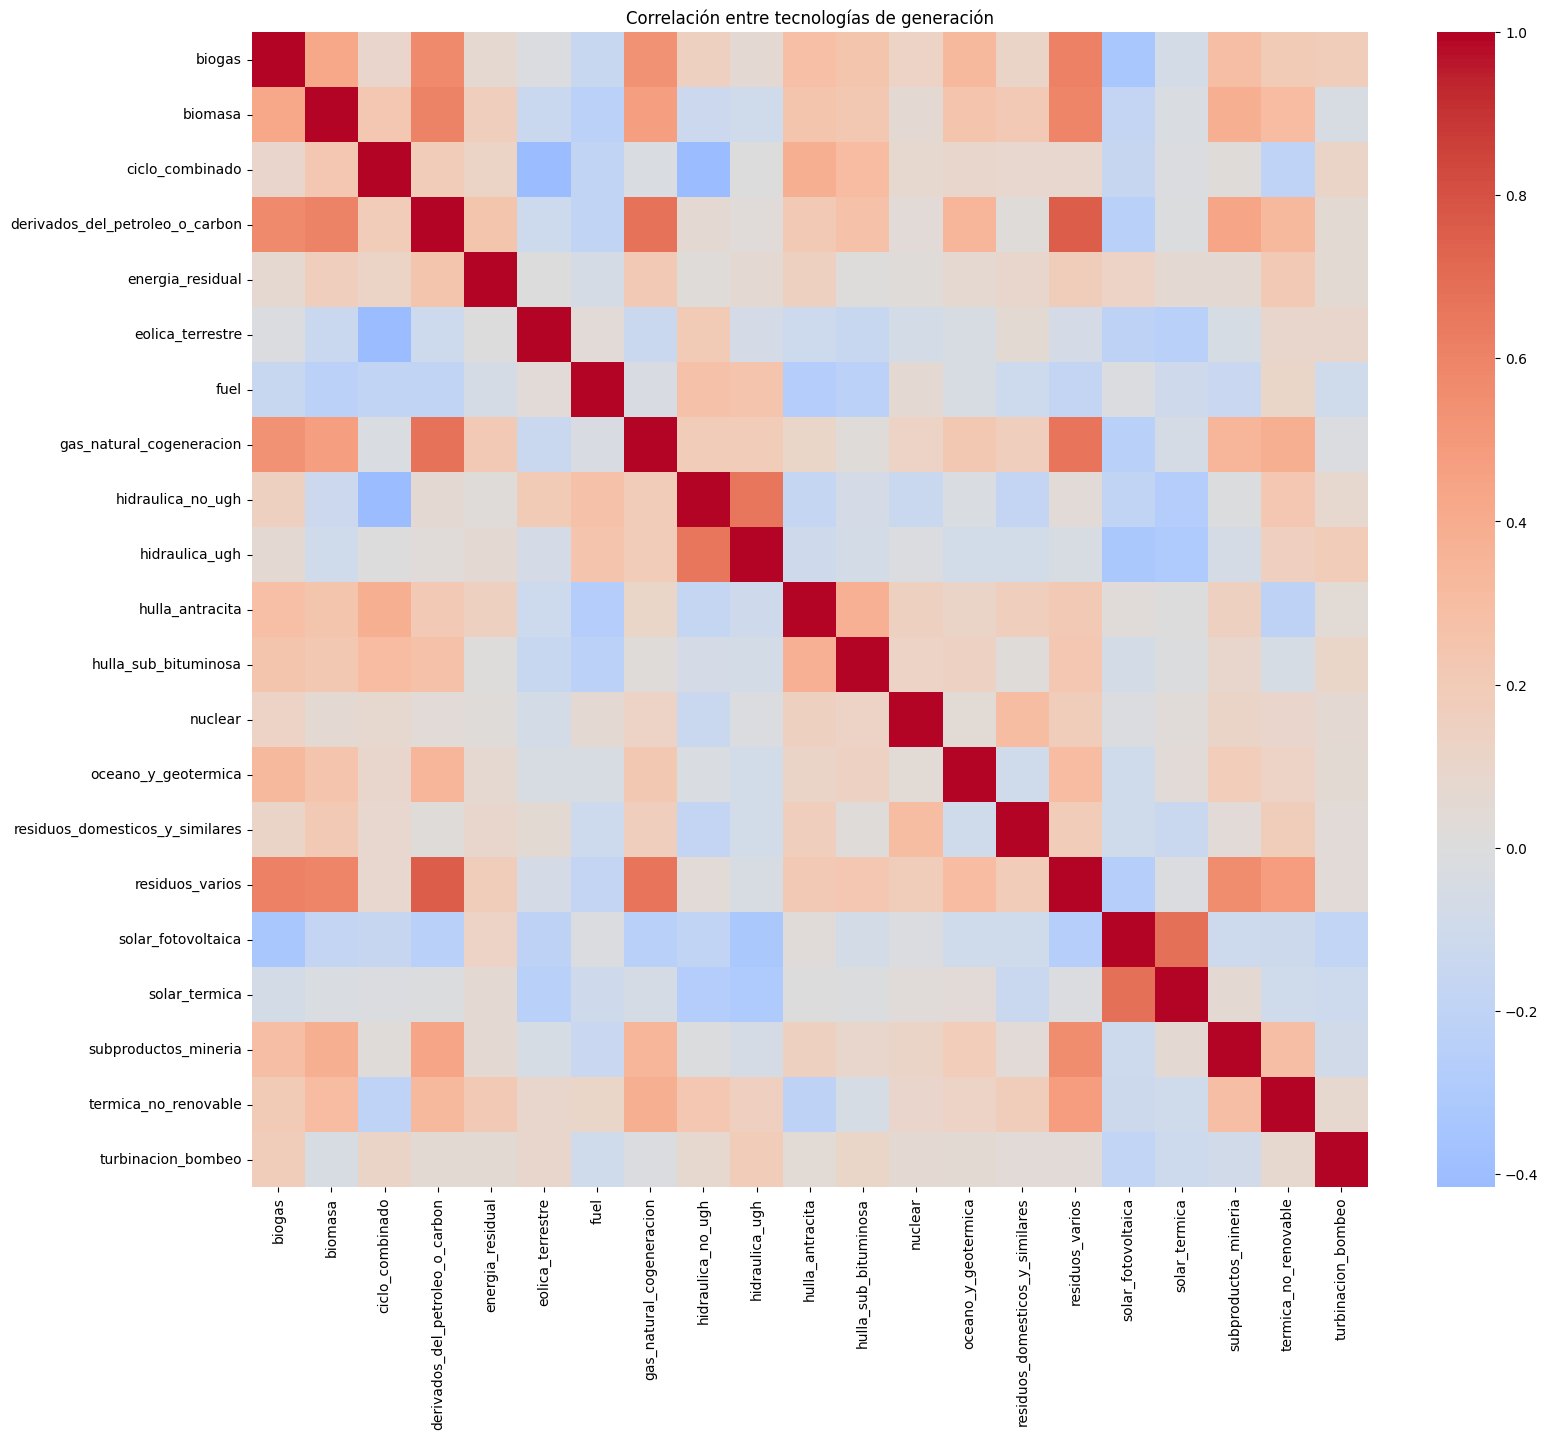


Pares de tecnologías con correlación ≥ 0.60:
                    tecnologia_1                    tecnologia_2  correlacion
                         biogas                 residuos_varios     0.614147
                        biomasa derivados_del_petroleo_o_carbon     0.602768
derivados_del_petroleo_o_carbon        gas_natural_cogeneracion     0.676707
derivados_del_petroleo_o_carbon                 residuos_varios     0.760544
       gas_natural_cogeneracion                 residuos_varios     0.666920
              hidraulica_no_ugh                  hidraulica_ugh     0.658267
             solar_fotovoltaica                   solar_termica     0.679311
Correlacion:

>= 0.60 -> posible agrupacion

>= 0.80 -> fuerte redundancia

>= 0.90 -> redundancia muy alta


VIF (Variance Inflation Factor) para detectar multicolinealidad:
                        variable       VIF
                         biogas 94.615097
                        nuclear 44.920469
                        biomasa 42.

In [5]:
# =========================
# 1 Mostrar la evolucion de la generacion por tecnologia y mes
# =========================

# Producción total y porcentaje por tipo de energía y mes

# Añadir columna de año
mensual_anual = df.groupby(['year', 'month'])[generacion_cols].sum()

# Obtener años únicos
años = mensual_anual.index.get_level_values('year').unique()

# Crear una gráfica para cada año
for año in años:
    # Filtrar datos del año
    datos_año = mensual_anual.xs(año, level=0)
    
    # Calcular porcentaje de aporte de cada tecnología respecto al total del año
    datos_año_pct = datos_año.div(datos_año.sum(axis=1), axis=0) * 100
    
    # Top 10 tecnologías que más aportan de media anual
    top_tecnologias = datos_año.mean().sort_values(ascending=False).head(10).index
    
    # Crear figura individual
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Graficar año
    datos_año_pct[top_tecnologias].plot(kind='line', marker='o', ax=ax)
    ax.set_title(f'Evolución mensual - {año}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xlabel('Mes')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



#Mostrar la evolución de la generación por tecnología y mes para los años 2020 y 2024 en una sola figura para memoria
# Versión vertical (una encima de otra)
años_mostrar = [2020, 2024]

fig, axes = plt.subplots(2, 1, figsize=(13, 12))

for i, año in enumerate(años_mostrar):
    datos_año = mensual_anual.xs(año, level=0)
    datos_año_pct = datos_año.div(datos_año.sum(axis=1), axis=0) * 100
    top_tecnologias = datos_año.mean().sort_values(ascending=False).head(8).index
    
    datos_año_pct[top_tecnologias].plot(
        kind='line', 
        marker='o', 
        ax=axes[i], 
        linewidth=2,
        markersize=6
    )
    
    axes[i].set_title(f'Evolución - {año}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Porcentaje del mix (%)', fontsize=12)
    axes[i].set_xlabel('Mes', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(0, 60)
    axes[i].set_xticks(range(12))
    axes[i].set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                             'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
    axes[i].legend(loc='upper center', fontsize=12)  # Leyenda en cada gráfica

plt.suptitle('Evolución mensual del mix de generación eléctrica (2020 - 2024)', 
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()




# Crear heatmap por mes y tecnología principal
mensual = df.groupby("month")[generacion_cols].sum()

# Ordenar las tecnologías por su aporte medio
tecnologias_top = mensual.mean().sort_values(ascending=False).index

datos_heatmap = mensual[tecnologias_top].T  # Transponer

plt.figure(figsize=(16, 8))
sns.heatmap(datos_heatmap, cmap='YlOrRd', annot=True, fmt='.0f', cbar_kws={'label': 'MWh'}, linewidths=0.5)
plt.title('Heatmap de producción por mes y tecnología', fontsize=14, fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Tecnología')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 2 Tabala resumen de estadisticas de las variables de generacion
# =========================

analisis = pd.DataFrame(index=generacion_cols)

df['total_generacion'] = df[generacion_cols].sum(axis=1)

analisis["media"] = df[generacion_cols].mean()
analisis["std"] = df[generacion_cols].std()
analisis["cv"] = (analisis["std"] / analisis["media"].abs())  # Coeficiente de variación
analisis["min"] = df[generacion_cols].min()
analisis["max"] = df[generacion_cols].max()
#analisis["p25"] = df[generacion_cols].quantile(0.25)
#analisis["p75"] = df[generacion_cols].quantile(0.75)
#analisis["rango_intercuartil"] = analisis["p75"] - analisis["p25"]

# Porcentaje de ceros
analisis["%_ceros"] = ((df[generacion_cols] == 0).mean() * 100)

# Porcentaje de días con generación positiva
analisis["%_positivos"] = ((df[generacion_cols] > 0).mean() * 100)

# Máximo porcentaje que aporta al total en un solo día
analisis["max_%_total"] = (
    (df[generacion_cols].div(df['total_generacion'], axis=0) * 100)
    .max()
)

# Media del porcentaje que aporta sobre el total
analisis["%_media_total"] = (
    (df[generacion_cols].div(df['total_generacion'], axis=0) * 100)
    .mean()
)

# Correlaciones con el precio:
analisis["pearson_price"] = [
    df[col].corr(df["price"], method="pearson")
    for col in generacion_cols
]

analisis["spearman_price"] = [
    df[col].corr(df["price"], method="spearman")
    for col in generacion_cols
]

# Ordenar de mayor a menor segun el % de aporte medio de cada tecnologia al total de generacion
analisis = analisis.sort_values("%_media_total", ascending=False)

display(analisis.round(3))

print(analisis.round(3).to_latex())


# =========================
# 3 Analisis de correlacion entre variables de generacion
# =========================

analisis_corr = pd.DataFrame(index=generacion_cols)

analisis_corr["media"] = df[generacion_cols].mean()
analisis_corr["std"] = df[generacion_cols].std()
analisis_corr["cv"] = ( analisis_corr["std"] / analisis_corr["media"].abs()) # Coeficiente de variación
analisis_corr["min"] = df[generacion_cols].min()
analisis_corr["max"] = df[generacion_cols].max()

analisis_corr["%_ceros"] = ( (df[generacion_cols] == 0).mean() * 100 )

analisis_corr["pearson_price"] = [
    df[col].corr(df["price"], method="pearson")
    for col in generacion_cols
]

analisis_corr["spearman_price"] = [
    df[col].corr(df["price"], method="spearman")
    for col in generacion_cols
]

analisis_corr = analisis_corr.sort_values(
    "pearson_price",
    key=abs,
    ascending=False
)

display(analisis_corr.round(3))


# =========================
# 4 Heatmap de correlacion entre variables de generacion
# =========================

corr_generacion = df[generacion_cols].corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr_generacion,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre tecnologías de generación")
plt.show()


#=========================
# 5 Detectar pares de variables con correlacion alta
# =========================
# pares de variables con correlacion alta (>= 0.60)
# Si la tienen, pueden agruparse o incluso eliminarse algunas de ellas para evitar
# multicolinealidad en modelos de ML
pares = []

for i in range(len(generacion_cols)):
    for j in range(i + 1, len(generacion_cols)):

        corr = corr_generacion.iloc[i, j]

        if abs(corr) >= 0.60:
            pares.append({
                "tecnologia_1": generacion_cols[i],
                "tecnologia_2": generacion_cols[j],
                "correlacion": corr
            })

pares = pd.DataFrame(pares)

pares.sort_values(
    "correlacion",
    key=abs,
    ascending=False
)

print("\nPares de tecnologías con correlación ≥ 0.60:\n", pares.to_string(index=False))
print("Correlacion:\n")
print(">= 0.60 -> posible agrupacion\n")
print(">= 0.80 -> fuerte redundancia\n")
print(">= 0.90 -> redundancia muy alta\n")


# =========================
# 6 Comprobar VIF (Variance Inflation Factor) 
# =========================

from statsmodels.stats.outliers_influence import variance_inflation_factor

generacion_cols_data = df[generacion_cols].copy()

vif = pd.DataFrame()
vif["variable"] = generacion_cols_data.columns
vif["VIF"] = [
    variance_inflation_factor(generacion_cols_data.values, i)
    for i in range(generacion_cols_data.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

print("\nVIF (Variance Inflation Factor) para detectar multicolinealidad:\n", vif.to_string(index=False))

print("VIF:\n")
print("< 5 -> aceptable\n")
print("5 - 10 -> moderada \n")
print(">= 10 -> fuerte\n")


# =========================
# 7 Comprobacion de la suma de las variables de generacion con el total_tipo_produccion
# =========================

suma_generacion = df[generacion_cols].sum(axis=1)

diferencia = suma_generacion - df["total_tipo_produccion"]

print("Filas donde total_tipo_produccion NO coincide:", (diferencia.abs() > 1e-6).sum())
print("Diferencia máxima absoluta:", diferencia.abs().max())

df_comprobacion = df.loc[
    diferencia.abs() > 1e-6,
    ["datetime", "total_tipo_produccion"] + generacion_cols
].copy()

df_comprobacion["suma_generacion"] = suma_generacion[
    diferencia.abs() > 1e-6
]

#display(df_comprobacion)

### 3 Estudio de agrupacion de las tecnologias de Generacion

1. Hacemos clusters (grupos)

    Usando la matriz de distancia de las correlaciones, agrupamos las variables mas
    parecidas entre si (menor distancia)

    Probamos con un rango de numero de grupos de 4-20

    Una vez hecho, seleccionamos el numero de grupos que mejor resultado ha dado 
    y los creamos. Para ello usamos Silhouette Score el cual mide qué tan bueno es un clustering, es decir, qué tan bien están separados y definidos los grupos. Esta medida toma un valor entre -1 a 1, siendo -1 un mal agrupamiento y 1 el mejor

2. Analizamos los grupos obtenidos para ver si tienen sentido y si son redundantes

    Comprobamos la correlacion entre las variables de cada grupo 

3. Analizamos la relacion de cada grupo con price

4. Analizamos la multicolinealidad de los grupos obtenidos para ver si son redundantes

    Mediante la medida VIF comprobamos si ha habido algun cambio entre el df antes y despues de clusterizar


,n_grupos,silhouette
0,4,0.199026
1,5,0.202749
2,6,0.205952
3,7,0.208123
4,8,0.197486
5,9,0.189529
6,10,0.247056
7,11,0.229227
8,12,0.211803
9,13,0.192817


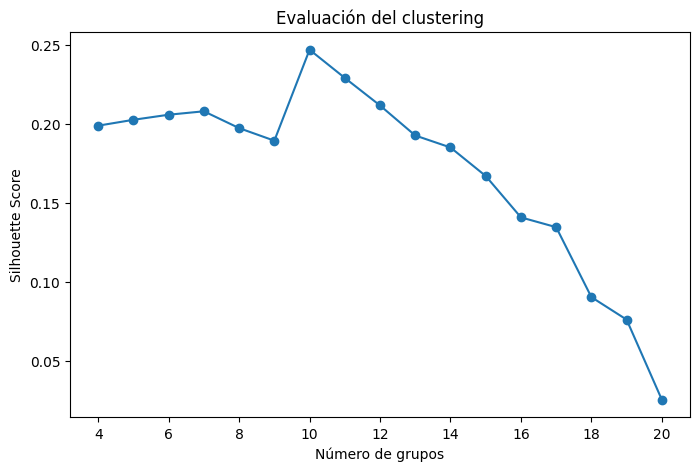


 Grupos con el número óptimo de clusters (10):


,tecnologia,grupo
12,nuclear,0
14,residuos_domesticos_y_similares,0
10,hulla_antracita,1
11,hulla_sub_bituminosa,1
0,biogas,2
1,biomasa,2
3,derivados_del_petroleo_o_carbon,2
7,gas_natural_cogeneracion,2
15,residuos_varios,2
19,termica_no_renovable,2



GRUPO 0
  - nuclear
  - residuos_domesticos_y_similares

GRUPO 1
  - hulla_antracita
  - hulla_sub_bituminosa

GRUPO 2
  - biogas
  - biomasa
  - derivados_del_petroleo_o_carbon
  - gas_natural_cogeneracion
  - residuos_varios
  - subproductos_mineria
  - termica_no_renovable

GRUPO 3
  - hidraulica_no_ugh
  - hidraulica_ugh

GRUPO 4
  - solar_fotovoltaica
  - solar_termica

GRUPO 5
  - energia_residual

GRUPO 6
  - ciclo_combinado
  - eolica_terrestre

GRUPO 7
  - fuel

GRUPO 8
  - oceano_y_geotermica

GRUPO 9
  - turbinacion_bombeo

Análisis de correlación interna de cada grupo:



,grupo,n_tecnologias,tecnologias,corr_media,corr_minima
0,0,2,"nuclear, residuos_domesticos_y_similares",nuclear 0.297836 re...,nuclear 0.297836 re...
1,1,2,"hulla_antracita, hulla_sub_bituminosa",hulla_antracita 0.379565 hulla_sub_bit...,hulla_antracita 0.379565 hulla_sub_bit...
2,2,7,"biogas, biomasa, derivados_del_petroleo_o_carb...",biogas 0.439279 bi...,biogas 0.198461 bi...
3,3,2,"hidraulica_no_ugh, hidraulica_ugh",hidraulica_no_ugh 0.658267 hidraulica_ugh ...,hidraulica_no_ugh 0.658267 hidraulica_ugh ...
4,4,2,"solar_fotovoltaica, solar_termica",solar_fotovoltaica 0.679311 solar_termica ...,solar_fotovoltaica 0.679311 solar_termica ...
5,5,1,energia_residual,NaN,NaN
6,6,2,"ciclo_combinado, eolica_terrestre",ciclo_combinado -0.414979 eolica_terrestre ...,ciclo_combinado -0.414979 eolica_terrestre ...
7,7,1,fuel,NaN,NaN
8,8,1,oceano_y_geotermica,NaN,NaN
9,9,1,turbinacion_bombeo,NaN,NaN



Correlación de cada grupo con el precio:



,pearson,spearman
grupo_2,-0.078,0.023
grupo_6,0.292,0.273
grupo_5,0.151,0.192
grupo_7,-0.425,-0.440
grupo_3,-0.135,-0.147
grupo_1,0.500,0.500
grupo_0,0.084,0.068
grupo_8,0.027,-0.044
grupo_4,-0.153,-0.096
grupo_9,0.133,0.125



VIF (Variance Inflation Factor) antes de agrupar:



,variable,VIF
0,biogas,94.615097
12,nuclear,44.920469
1,biomasa,42.979476
7,gas_natural_cogeneracion,35.288155
15,residuos_varios,28.943047
14,residuos_domesticos_y_similares,24.777103
8,hidraulica_no_ugh,20.676332
3,derivados_del_petroleo_o_carbon,13.110049
9,hidraulica_ugh,8.781020
10,hulla_antracita,7.423919



VIF (Variance Inflation Factor) después de agrupar:



,variable,VIF
0,grupo_0,20.504557
6,grupo_6,9.402317
2,grupo_2,5.920752
1,grupo_1,4.498070
3,grupo_3,4.296098
8,grupo_8,2.400887
4,grupo_4,1.969000
9,grupo_9,1.742864
5,grupo_5,1.731738
7,grupo_7,1.546889


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from statsmodels.stats.outliers_influence import variance_inflation_factor


generacion_cols = [
    "biogas", "biomasa", "ciclo_combinado",
    "derivados_del_petroleo_o_carbon", "energia_residual",
    "eolica_terrestre", "fuel", "gas_natural_cogeneracion",
    "hidraulica_no_ugh", "hidraulica_ugh",
    "hulla_antracita", "hulla_sub_bituminosa",
    "nuclear", "oceano_y_geotermica",
    "residuos_domesticos_y_similares", "residuos_varios",
    "solar_fotovoltaica", "solar_termica",
    "subproductos_mineria", "termica_no_renovable",
    "turbinacion_bombeo"
]

# Recuerda 1 = correlacion positiva perfecta, -1 = correlacion negativa perfecta, 0 = sin correlacion
corr = df[generacion_cols].corr()

# Al restarle 1 a los valores absolutos de la correlacion obtenemos
# una matriz de distancia donde 0 = máxima correlación (positiva o negativa) y
# 1 = sin correlación (Valores mas bajos = mas similares)
distancia = 1 - corr.abs()
#Convierte el DataFrame a un array de NumPy
distancia = distancia.to_numpy(copy=True)

#La diagonal representa la distancia de cada variable consigo misma (siempre debe er 0) 
np.fill_diagonal(distancia, 0)


# =========================
# 1 Clusterizar las tecnologias de generacion para detectar redundancias
# =========================

resultados_clustering = []

# Probamos clusters (grupos) de tamaño 2 a 10 y evaluamos la calidad de cada uno usando Silhouette Score
for n in range(4, 21):

    #Precomputed porque estamos usando una matriz de distancia ya calculada y usamos el promedio entre grupos
    modelo = AgglomerativeClustering(n_clusters=n, metric="precomputed", linkage="average")

    #Asigna cada variable a un grupo (0, 1, 2, ...) usando la matriz de distancia
    etiquetas = modelo.fit_predict(distancia)

    #silhouette_score: 1 = grupos perfectamente separados, 0 = grupos superpuestos, -1 = mala clasificación
    silhouette = silhouette_score(distancia, etiquetas, metric="precomputed")

    resultados_clustering.append({
        "n_grupos": n,
        "silhouette": silhouette
    })

resultados_clustering = pd.DataFrame(resultados_clustering)

display(resultados_clustering)

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_clustering["n_grupos"],
    resultados_clustering["silhouette"],
    marker="o"
)

plt.xlabel("Número de grupos")
plt.ylabel("Silhouette Score")
plt.title("Evaluación del clustering")

plt.show()



# Obtenemos el numero mas optimo de grupos que mejor resultado ha dado (mayor silhouette score)
n_optimo = resultados_clustering.loc[
    resultados_clustering["silhouette"].idxmax(),
    "n_grupos"
]

#Volvemos a ejecutar el clustering, esta vez con el numero optimo de grupos
modelo = AgglomerativeClustering(
    n_clusters=int(n_optimo),
    metric="precomputed",
    linkage="average"
)

etiquetas = modelo.fit_predict(distancia)

grupos = pd.DataFrame({
    "tecnologia": generacion_cols,
    "grupo": etiquetas
})

print(f"\n Grupos con el número óptimo de clusters ({n_optimo}):")
display(
    grupos.sort_values("grupo")
)

# mostrar las tecnologias agrupadas por grupo
for grupo, datos in grupos.groupby("grupo"):

    print(f"\nGRUPO {grupo}")
    
    for tecnologia in datos["tecnologia"]:
        print("  -", tecnologia)



# =========================
# 2 Analizamos los grupos obtenidos para ver si tienen sentido y si son redundantes
# =========================

# Analizar la correlación interna de cada grupo
analisis_grupos = []

for grupo, datos in grupos.groupby("grupo"):

    tecnologias = datos["tecnologia"].tolist()

    if len(tecnologias) > 1:

        subcorr = corr.loc[tecnologias, tecnologias]

        valores = subcorr.where(np.invert(np.eye(len(tecnologias), dtype=bool)))

        correlacion_media = valores.mean()
        correlacion_minima = valores.min()

    else:
        correlacion_media = np.nan
        correlacion_minima = np.nan

    analisis_grupos.append({
        "grupo": grupo,
        "n_tecnologias": len(tecnologias),
        "tecnologias": ", ".join(tecnologias),
        "corr_media": correlacion_media,
        "corr_minima": correlacion_minima
    })

analisis_grupos = pd.DataFrame(analisis_grupos)

print("\nAnálisis de correlación interna de cada grupo:\n")
display(
    analisis_grupos.round(3)
)

# =========================
# 3 Analizamos la relacion de cada grupo con price
# =========================

# Analizar la relacion de cada grupo con price

for grupo, datos in grupos.groupby("grupo"):

    tecnologias = datos["tecnologia"].tolist()

    nombre = f"grupo_{grupo}"

    df[nombre] = df[tecnologias].sum(axis=1)


corr_grupos_price = {}

for grupo in grupos["grupo"].unique():

    nombre = f"grupo_{grupo}"

    corr_grupos_price[nombre] = {
        "pearson": df[nombre].corr(df["price"]),
        "spearman": df[nombre].corr(
            df["price"],
            method="spearman"
        )
    }

corr_grupos_price = pd.DataFrame(
    corr_grupos_price
).T


print("\nCorrelación de cada grupo con el precio:\n")
display(
    corr_grupos_price.round(3)
)


# =========================
# 4 Analizamos la multicolinealidad de los grupos obtenidos para ver si son redundantes
# =========================

# Vemos el VIF antes y después

def calcular_vif(data, columnas):

    X = data[columnas].copy()

    resultado = pd.DataFrame({
        "variable": columnas,
        "VIF": [
            variance_inflation_factor(
                X.values,
                i
            )
            for i in range(len(columnas))
        ]
    })

    return resultado.sort_values(
        "VIF",
        ascending=False
    )


vif_original = calcular_vif(
    df,
    generacion_cols
)

print("\nVIF (Variance Inflation Factor) antes de agrupar:\n")
display(vif_original)


columnas_grupos = [
    f"grupo_{g}"
    for g in sorted(grupos["grupo"].unique())
]

vif_agrupado = calcular_vif(
    df,
    columnas_grupos
)

print("\nVIF (Variance Inflation Factor) después de agrupar:\n")
display(vif_agrupado)

### Conclusion de Eliminacion y Agrupacion de variables de Generacion del dataset

1. Finalmente, he dicido deshacerme de:

    * fuel: a pesar de tener una correlacion negativa considerable con el precio, casi todos sus valores son cercanos a 0, por lo que no aporta practicamente nada al mix de generacion

    * oceano_y_geotermica: ocurre lo mismo que fuel, es una energia emergente que acutalmente tiene casi nula presencia en el mercado y aporta poca informacion al dataset.
    
    * energia_residual: de la misma manera, este indicador aglomera la energia generada de forma residual de distintas maneras y cuenta con un olo 0,008 % aportacion media, es decir muy poca presencia entre el resto de variables

    * subproductos_mineria: pese a ser una energia bastante estable, solo representa un 0,08 % de la generación de media y su correlación con precio escasi 0. Por lo que no aporta informacion suficiente 

    * total_tipo_produccion: es un indicador que proviene de la suma de todos los datos del grupo PBF. En nuestro caso, no hemos seleccionado todos los elementos de ese grupo, solo tecnologias de generacion, por lo que al contrastarlos vemos que no coinciden. Dado que ya tenemos el dato de generacion de energia de todas las tecologias que nos interesan podemos prescindir de este

    
2. He decidido agrupar las siguientes tecnologias:

    * Hidraulica: hidraulica_no_ugh, hidraulica_ugh

        La Hidráulica UGH de media aporta 2574 MWh mietras que la Hidráulica no UGH aporta de media 592 MWh. Aunque tienen escalas diferentes, ambas representan generación hidroeléctrica. Se agrupan porque pertenecen a la misma fuente energética y presentan un comportamiento temporal relacionado, aunque su contribución al volumen total de generación sea diferente. Ojo porque ambas tienen correlacion negativa con el precio, pero una mas que otra (posible perdida de informacion)


    * Solar: solar_fotovoltaica, solar_termica
        tienen un comportamiento temporal muy relacionado porque ambas dependen fundamentalmente de la disponibilidad de radiación solar.
        La Fotovoltaica de media aporta 3268 MWh y Solar térmica aporta de media 508 MWh. La térmica representa una parte mucho menor, pero ambas tienen un perfil diario y estacional asociado al recurso solar. Además, sus correlaciones con el precio son similares:
        
        Fotovoltaica: Pearson −0,151, Spearman −0,072
        
        Solar térmica: Pearson −0,125, Spearman −0,075

    * Carbon: hulla_antracita y hulla_sub_bituminosa

        Ambas son carbón aunque la sub-bituminosa es de menor calidad. Pertenecen a la misma categoría tecnológica y presentan características de generación suficientemente similares como para justificar su agregación

    * Residuos: residuos_varios, residuos_domesticos_y_similares 

        Tiene sentido porque todas son fuentes de generación a partir de desechos, con perfiles de generacion bajos y relativamente estables (coeficiente de variacion no muy elevado) que no dependen del clima (a diferencia de solar o eólica)

In [ ]:
#Volvemos a cargar el dataset original para hacer la agrupación de tecnologías y eliminar las originales
df = pd.read_csv("Dataset_Unificado_2020_2024.csv", sep=";")

# ==============================
# AGRUPACION DE TECNOLOGIAS
# ==============================

# Hidráulica
df["hidraulica"] = (df["hidraulica_no_ugh"] + df["hidraulica_ugh"])

# Solar
df["solar"] = (df["solar_fotovoltaica"] + df["solar_termica"])

# Carbón
df["carbon"] = (df["hulla_antracita"] + df["hulla_sub_bituminosa"])

# Residuos
df["residuos"] = (df["residuos_varios"] + df["residuos_domesticos_y_similares"])


# ==============================
# ELIMINAR VARIABLES ORIGINALES
# ==============================

columnas_eliminar = [
    "fuel",
    "oceano_y_geotermica",
    "energia_residual",
    "subproductos_mineria",
    "total_tipo_produccion",

    "hidraulica_no_ugh",
    "hidraulica_ugh",

    "solar_fotovoltaica",
    "solar_termica",

    "hulla_antracita",
    "hulla_sub_bituminosa",

    "residuos_varios",
    "residuos_domesticos_y_similares"
]

df = df.drop(columns=columnas_eliminar)

print(df.head(3))

df.to_csv("Dataset_Unificado1.csv", index=False, sep=';')


              datetime    demand  year  month  day  dayofweek  is_weekend  \
0  2020-01-01 00:00:00  23001.00  2020      1    1          2           0   
1  2020-01-01 01:00:00  22253.67  2020      1    1          2           0   
2  2020-01-01 02:00:00  20999.50  2020      1    1          2           0   

   biogas  biomasa  ciclo_combinado  derivados_del_petroleo_o_carbon  \
0  89.980  273.283         4375.106                          125.606   
1  90.457  269.422         4538.635                          116.100   
2  85.455  261.432         4177.421                          115.889   

   eolica_terrestre  gas_natural_cogeneracion   nuclear  termica_no_renovable  \
0          1546.640                  2366.711  7108.765                   0.0   
1          1589.363                  2333.025  7104.832                   0.0   
2          1661.273                  2328.178  7108.460                   0.0   

   turbinacion_bombeo  price  hour  hidraulica  solar   carbon  residuos  
0 